This notebook was used to load the original images, visualize random samples, verify class distribution and resize images into 256x256. We indeed saved the resized images in a new folder to accelerate the loading process for both tasks. The present outputs are relative to the 128x128 resize that was tried out but ended up beeing unappropriate as it worsens too much image quality.  

## 🛜 Drive and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import os
import cv2
import numpy as np
import glob

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.gridspec as gridspec


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## 📸 Data loading
Dimensioni originali

In [ ]:
from tqdm import tqdm
BASE_ROOT = Path("/content/drive/MyDrive/PROGETTO AI/Assignment_25_26")

In [ ]:
train_dir= BASE_ROOT /'training_images'
train_meta= BASE_ROOT/'training_metadata.xlsx'

In [ ]:
# @title Load dataset
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

def load_dataset(images_dir, metadata_path, target_size=(256, 256)):
    """
    Caricamento BLINDATO con MAPPING NOMI FILE.
    Restituisce anche la lista dei nomi dei file caricati per poter verificare
    che X[i] corrisponda davvero al file 'nome_file.png'.
    Questo è necessario perchè ci sono immagini chiamate, ad esempio, USERID_1, USERID_2 ecc, quindi l'indice
    delle immagini non corrisponde esattamente.
    """
    print(f"--- Inizio Caricamento Blindato (Excel-First) ---")

    # 1. Leggi il file Excel
    df = pd.read_excel(metadata_path)
    # Pulizia nomi file
    df['US'] = df['US'].astype(str).str.strip()
    df['MASK'] = df['MASK'].astype(str).str.strip()

    total_rows = len(df)
    print(f"Excel letto. Totale righe da processare: {total_rows}")

    X_images = []
    Y_masks = []
    y_labels = []

    # NUOVO: Lista per salvare i nomi dei file caricati
    loaded_filenames = []

    missing_files = []
    loaded_count = 0

    # 2. Itera sulle righe dell'Excel
    for index, row in tqdm(df.iterrows(), total=total_rows):
        img_filename = row['US']
        mask_filename = row['MASK']
        label = int(row['LABEL'])

        # Costruisci i percorsi completi
        img_path = os.path.join(images_dir, img_filename)
        mask_path = os.path.join(images_dir, mask_filename)

        # --- CONTROLLI DI ESISTENZA ---
        if not os.path.exists(img_path):
            missing_files.append(img_filename)
            continue
        if not os.path.exists(mask_path):
            missing_files.append(mask_filename)
            continue

        # --- CARICAMENTO ---
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print(f"Errore di lettura CV2 per {img_filename}")
            continue

        # --- PREPROCESSING ---
        # 1. BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Resize
        img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        # --- APPEND ---
        X_images.append(img_resized)
        Y_masks.append(mask_resized)
        y_labels.append(label)

        # NUOVO: Salviamo il nome del file (sincronizzato con l'indice)
        loaded_filenames.append(img_filename)

        loaded_count += 1

    # --- RIEPILOGO ---
    print(f"\n--- Caricamento Completato ---")
    print(f"Righe Excel processate: {total_rows}")
    print(f"Immagini caricate con successo: {loaded_count}")
    print(f"File mancanti su disco: {len(missing_files)}")

    # Conversione Numpy
    X = np.array(X_images)
    Y_seg = np.array(Y_masks)
    Y_seg = np.expand_dims(Y_seg, axis=-1)
    y_cls = np.array(y_labels)

    # NUOVO: Restituiamo anche la lista dei nomi
    return X, Y_seg, y_cls, loaded_filenames

In [ ]:
X_train_val, X_train_val_masks, y_train_val, loaded_filenames = load_dataset(train_dir, train_meta, target_size=(128, 128))

print(f"Shape Immagini: {X_train_val.shape}") # Dovrebbe essere (N, 256, 256, 3)
print(f"Shape Maschere: {X_train_val_masks.shape}") # Dovrebbe essere (N, 256, 256, 1)
print(f"Esempio Label: {y_train_val[:5]}")      # Output atteso: [2 2 2 2 2] (se inizia con normal)

--- Inizio Caricamento Blindato (Excel-First) ---
Excel letto. Totale righe da processare: 1503


100%|██████████| 1503/1503 [41:01<00:00,  1.64s/it]


--- Caricamento Completato ---
Righe Excel processate: 1503
Immagini caricate con successo: 1503
File mancanti su disco: 0
Shape Immagini: (1503, 128, 128, 3)
Shape Maschere: (1503, 128, 128, 1)
Esempio Label: [2 2 2 2 2]


In [ ]:
# @title Random Samples Visualization
import matplotlib.pyplot as plt
import numpy as np
import random

# Definizione mappa classi
class_map = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}

def visualize_random_samples(X, y, filenames, num_samples=9):
    """
    Visualizza campioni casuali mostrando anche il nome del file originale.
    """
    plt.figure(figsize=(15, 15))

    # Genera indici casuali
    # Assicuriamoci di non chiedere più campioni di quanti ne abbiamo
    num_samples = min(num_samples, len(X))
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i + 1)

        # Gestione visualizzazione (se float 0-1 o uint8 0-255)
        img = X[idx]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        plt.imshow(img)

        label_idx = y[idx]
        label_name = class_map.get(label_idx, "Unknown")

        # Recupera il nome del file corrispondente all'indice
        file_name = filenames[idx]

        # Titolo con tutte le info (uso \n per andare a capo)
        plt.title(f"Idx: {idx} | {file_name}\nClass: {label_name} ({label_idx})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

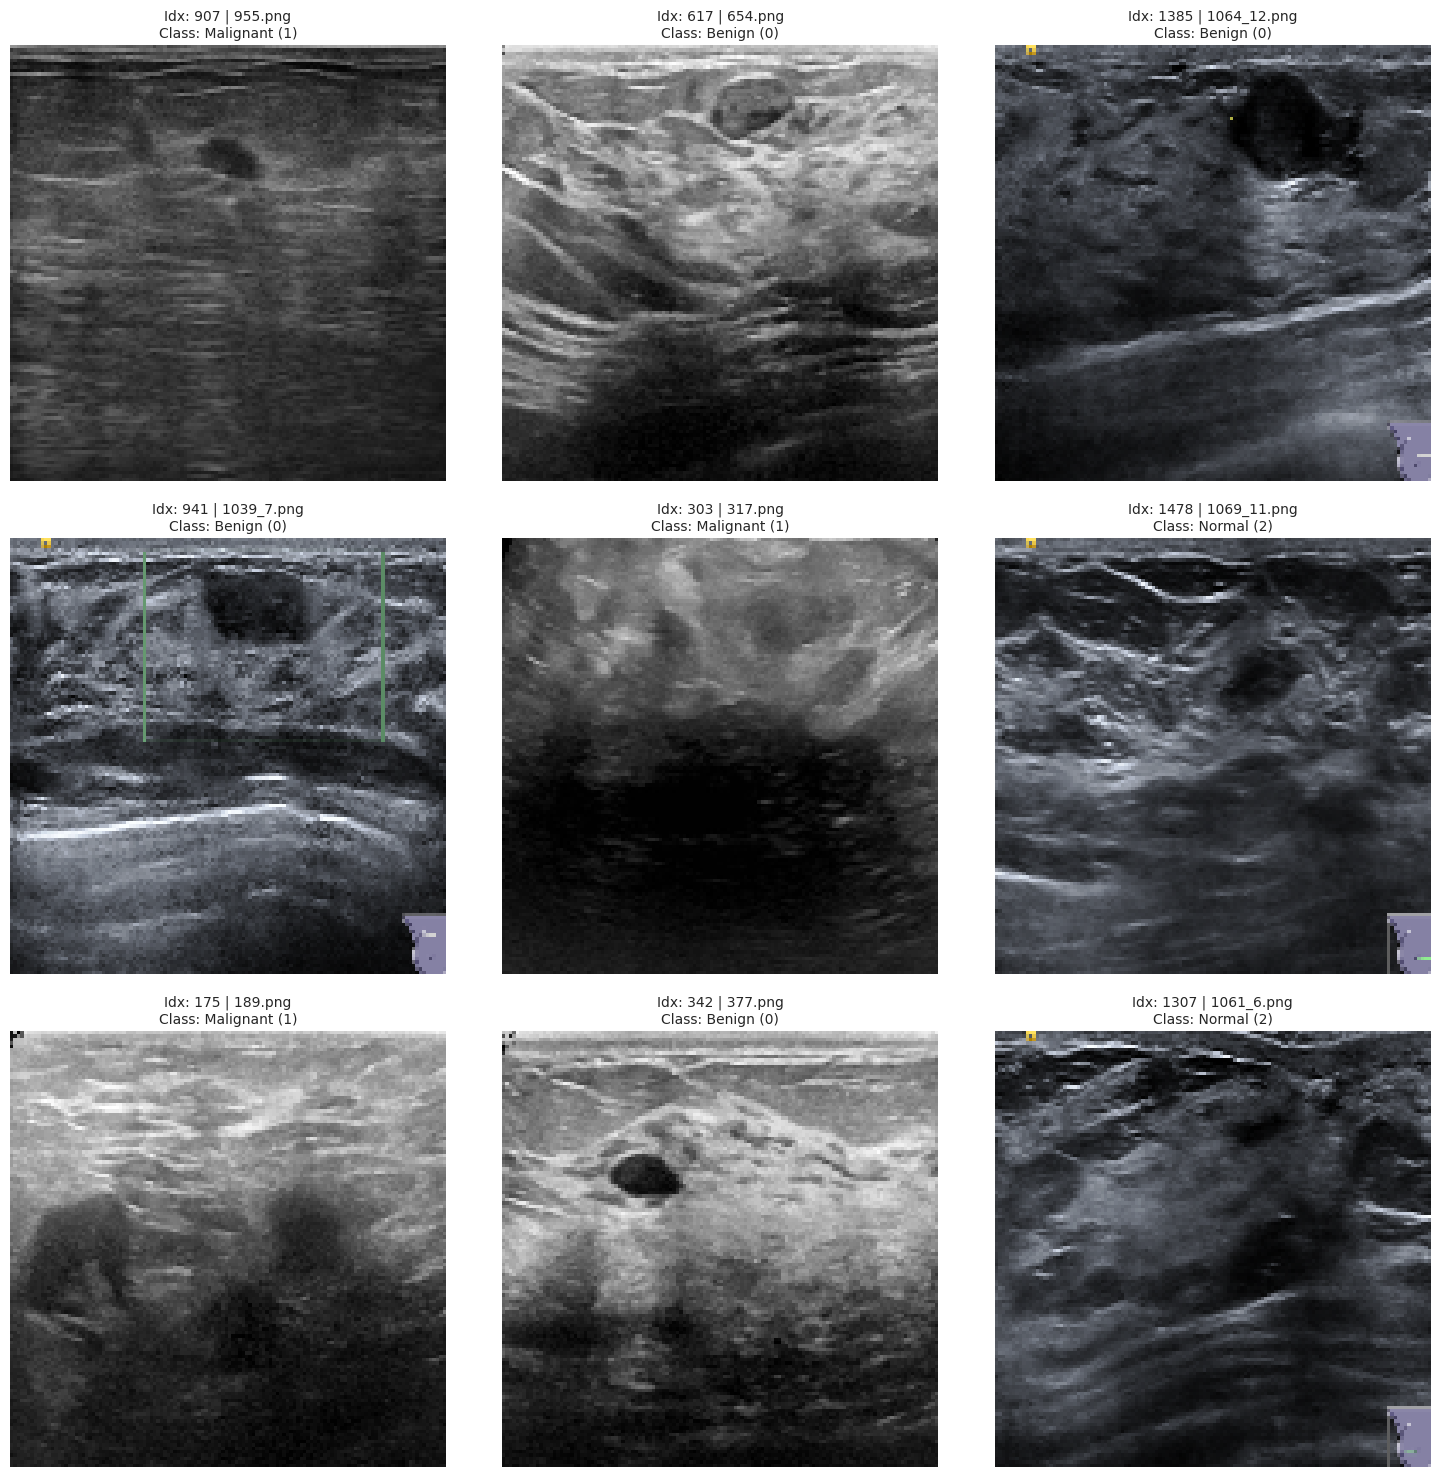

In [ ]:
visualize_random_samples(X_train_val, y_train_val, loaded_filenames)

1. ANALISI DISTRIBUZIONE GENERALE DEL DATASET
 Label_Index Class_Name  Count  Percentage
           0     Benign    679   45.176314
           1  Malignant    364   24.218230
           2     Normal    460   30.605456


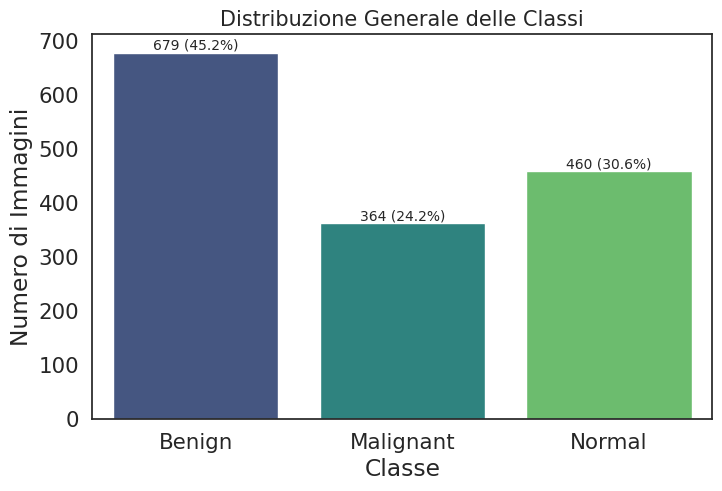


2. ANALISI BIAS DA ANNOTAZIONI (Scritte/Righelli)
Cerco immagini con pixel 'bianco puro' (tipici di caliper e testi digitali)...

Trovate 1464 immagini con annotazioni su 1503 totali.

Distribuzione classi nel subset 'Annotato':
 Label_Index Class_Name  Count  Percentage
           0     Benign    663   45.286885
           1  Malignant    342   23.360656
           2     Normal    459   31.352459


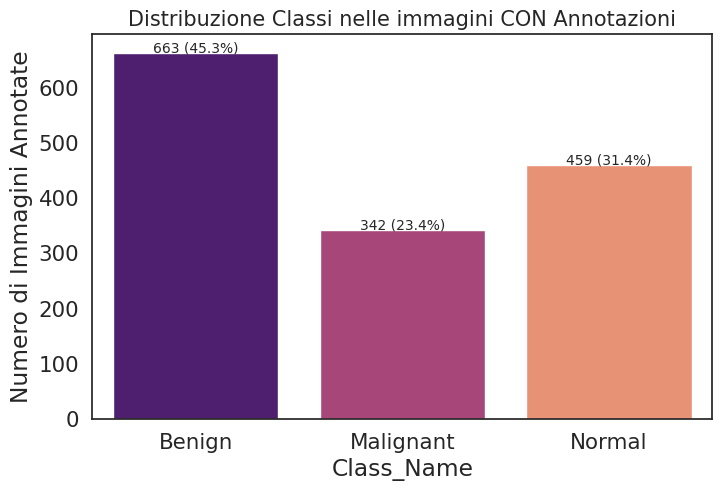


Esempi visuali di immagini rilevate come 'Annotate':


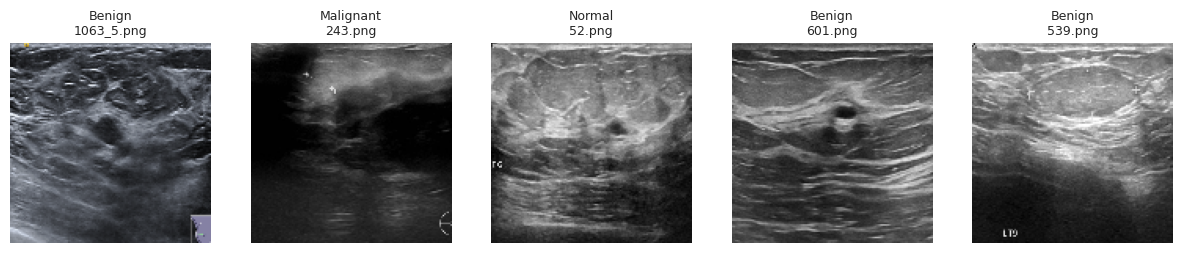

In [ ]:
# @title Visualize distributions

def analyze_class_distributions(X, y, filenames=None):
    """
    Esegue un'analisi completa:
    1. Distribuzione Generale delle classi.
    2. Rilevamento di immagini con 'Annotazioni' (scritte/righelli) e loro distribuzione.
    """

    # --- 1. DISTRIBUZIONE GENERALE ---
    print("="*60)
    print("1. ANALISI DISTRIBUZIONE GENERALE DEL DATASET")
    print("="*60)

    # Conta occorrenze
    unique, counts = np.unique(y, return_counts=True)
    total_samples = len(y)

    # Crea DataFrame
    df_gen = pd.DataFrame({
        'Label_Index': unique,
        'Class_Name': [class_map[i] for i in unique],
        'Count': counts
    })
    df_gen['Percentage'] = (df_gen['Count'] / total_samples) * 100

    print(df_gen.to_string(index=False))

    # Plot Generale
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='Class_Name', y='Count', data=df_gen, palette='viridis', hue='Class_Name', legend=False)
    plt.title('Distribuzione Generale delle Classi', fontsize=15)
    plt.ylabel('Numero di Immagini')
    plt.xlabel('Classe')

    # Etichette sulle barre
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        if not np.isnan(height):
            ax.text(p.get_x() + p.get_width()/2., height + 5,
                    f'{int(height)} ({df_gen.iloc[i]["Percentage"]:.1f}%)',
                    ha="center", fontsize=10)
    plt.show()

    # --- 2. ANALISI BIAS ANNOTAZIONI (Testo/Righelli) ---
    print("\n" + "="*60)
    print("2. ANALISI BIAS DA ANNOTAZIONI (Scritte/Righelli)")
    print("="*60)
    print("Cerco immagini con pixel 'bianco puro' (tipici di caliper e testi digitali)...")

    # Parametri per rilevare scritte
    # Se le immagini sono uint8 (0-255) usiamo > 240, se float (0-1) usiamo > 0.94
    is_float = X.max() <= 1.0
    threshold_val = 0.94 if is_float else 150
    min_pixels = 50  # Numero minimo di pixel bianchi per dire "c'è una scritta"

    annotated_indices = []

    for i in range(len(X)):
        img = X[i]
        # Se RGB, facciamo la media o prendiamo il max sui canali per trovare il bianco
        # Il bianco digitale è (255, 255, 255), quindi la media è 255.
        if img.ndim == 3:
            vals = np.mean(img, axis=-1)
        else:
            vals = img

        count_white = np.sum(vals > threshold_val)

        if count_white > min_pixels:
            annotated_indices.append(i)

    num_annotated = len(annotated_indices)
    print(f"\nTrovate {num_annotated} immagini con annotazioni su {total_samples} totali.")

    if num_annotated > 0:
        # Calcoliamo la distribuzione SOLO su queste immagini
        y_annotated = y[annotated_indices]
        unique_ann, counts_ann = np.unique(y_annotated, return_counts=True)

        df_ann = pd.DataFrame({
            'Label_Index': unique_ann,
            'Class_Name': [class_map[i] for i in unique_ann],
            'Count': counts_ann
        })
        df_ann['Percentage'] = (df_ann['Count'] / num_annotated) * 100

        print("\nDistribuzione classi nel subset 'Annotato':")
        print(df_ann.to_string(index=False))

        # Plot Confronto
        plt.figure(figsize=(8, 5))
        ax2 = sns.barplot(x='Class_Name', y='Count', data=df_ann, palette='magma', hue='Class_Name', legend=False)
        plt.title('Distribuzione Classi nelle immagini CON Annotazioni', fontsize=15)
        plt.ylabel('Numero di Immagini Annotate')

        for i, p in enumerate(ax2.patches):
            height = p.get_height()
            if not np.isnan(height):
                ax2.text(p.get_x() + p.get_width()/2., height + 1,
                        f'{int(height)} ({df_ann.iloc[i]["Percentage"]:.1f}%)',
                        ha="center", fontsize=10)
        plt.show()

        # Visualizziamo alcuni esempi "incriminati"
        print("\nEsempi visuali di immagini rilevate come 'Annotate':")
        plt.figure(figsize=(15, 4))
        # Mostriamo max 5 esempi a caso
        sample_indices = random.sample(annotated_indices, min(5, num_annotated))

        for i, idx in enumerate(sample_indices):
            plt.subplot(1, 5, i + 1)
            img_show = X[idx]
            # Converti per visualizzazione se necessario
            if is_float: img_show = (img_show * 255).astype(np.uint8)
            else: img_show = img_show.astype(np.uint8)

            plt.imshow(img_show)
            label_name = class_map[y[idx]]
            fname = filenames[idx] if filenames else f"Idx {idx}"
            plt.title(f"{label_name}\n{fname}", fontsize=9)
            plt.axis('off')
        plt.show()

    else:
        print("Nessuna annotazione significativa rilevata con le soglie attuali.")

# --- ESECUZIONE ---
# Assicurati di passare i dati caricati (X_train_val, y_train_val) e opzionalmente i nomi file
# Se non hai la lista dei nomi, puoi togliere l'argomento filenames
analyze_class_distributions(X_train_val, y_train_val, filenames=loaded_filenames)

Anche variando la soglia di pixel considerati come "annotazioni", la distribuzione delle varie classi è coerente -> confermo che non tutte le immagini con annotazioni appartengono alla stessa classe (che potrebbe causare bias)

## Salvataggio X_train_val 256x256

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np

def export_to_png(X, y, masks, filenames=None, output_dir='Dataset_Processato'):
    """
    Salva il dataset come file PNG singoli e crea un CSV per le etichette.
    Struttura:
      /Dataset_Processato
          /images
             img_0.png
             img_1.png
          /masks
             img_0.png
             img_1.png
          labels.csv
    """
    # 1. Crea le cartelle
    images_dir = os.path.join(output_dir, 'images')
    masks_dir = os.path.join(output_dir, 'masks')

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)

    print(f"Esportazione in corso in: {output_dir} ...")

    data_records = []

    # 2. Loop su tutte le immagini
    for i in range(len(X)):
        # --- Preparazione Immagine ---
        img = X[i]
        # Se è float (0-1), convertiamo in 0-255 uint8
        if img.max() <= 1.0 and (img.dtype == 'float32' or img.dtype == 'float64'):
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

        # --- Preparazione Maschera ---
        msk = masks[i]
        # Convertiamo la maschera in 0-255 (così si vede bianca e nera)
        if msk.max() <= 1.0:
            msk = (msk * 255).astype(np.uint8)
        else:
            msk = msk.astype(np.uint8)

        # --- Nome del file ---
        # Se abbiamo i nomi originali usiamo quelli, altrimenti ne inventiamo uno
        if filenames is not None:
            # Puliamo il nome da percorsi precedenti
            base_name = os.path.basename(filenames[i])
            # Assicuriamoci che finisca per .png (alcuni originali potrebbero essere .jpg)
            save_name = os.path.splitext(base_name)[0] + ".png"
        else:
            save_name = f"image_{i:05d}.png"

        # --- Salvataggio Fisico ---
        # Salviamo immagine
        cv2.imwrite(os.path.join(images_dir, save_name), img)

        # Salviamo maschera (stesso nome)
        cv2.imwrite(os.path.join(masks_dir, save_name), msk)

        # --- Salvataggio Dati per CSV ---
        data_records.append({
            'filename': save_name,
            'class_index': y[i],
            # Se vuoi puoi aggiungere qui anche il nome della classe se hai la mappa
            # 'class_name': class_map[y[i]]
        })

        if i % 100 == 0:
            print(f"Salvate {i}/{len(X)} immagini...")

    # 3. Creazione file CSV (Excel)
    df = pd.DataFrame(data_records)
    csv_path = os.path.join(output_dir, 'labels.csv')
    df.to_csv(csv_path, index=False)

    print("="*50)
    print(f"✅ Esportazione completata!")
    print(f"📂 Immagini in: {images_dir}")
    print(f"📂 Maschere in: {masks_dir}")
    print(f"📝 File etichette: {csv_path}")

# --- ESECUZIONE ---
# Sostituisci 'masks_train_val' con il nome della tua variabile che contiene le maschere
save_path='/content/drive/MyDrive/PROGETTO AI/DATA RESIZED128'
export_to_png(X_train_val, y_train_val, masks=X_train_val_masks, filenames=loaded_filenames, output_dir=save_path)

Esportazione in corso in: /content/drive/MyDrive/PROGETTO AI/DATA RESIZED128 ...
Salvate 0/1503 immagini...
Salvate 100/1503 immagini...
Salvate 200/1503 immagini...
Salvate 300/1503 immagini...
Salvate 400/1503 immagini...
Salvate 500/1503 immagini...
Salvate 600/1503 immagini...
Salvate 700/1503 immagini...
Salvate 800/1503 immagini...
Salvate 900/1503 immagini...
Salvate 1000/1503 immagini...
Salvate 1100/1503 immagini...
Salvate 1200/1503 immagini...
Salvate 1300/1503 immagini...
Salvate 1400/1503 immagini...
Salvate 1500/1503 immagini...
✅ Esportazione completata!
📂 Immagini in: /content/drive/MyDrive/PROGETTO AI/DATA RESIZED128/images
📂 Maschere in: /content/drive/MyDrive/PROGETTO AI/DATA RESIZED128/masks
📝 File etichette: /content/drive/MyDrive/PROGETTO AI/DATA RESIZED128/labels.csv
